# Use Case 1: Loan Approval Prediction

## Problem Statement

Build a classification model to predict whether a customer loan application will be approved or rejected.

### Target Variable
- Loan_Status

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
data = pd.read_csv('/content/drive/MyDrive/Machine_Learning/datasets/preprocessed_hdfc_loan_data.csv')

In [5]:
data.head()

,Unnamed: 0,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,CIBIL_Score,Employment_Status,Existing_EMIs,Debt_to_Income_Ratio,Education,Property_Area,Loan_Status
0,0,56976,0,8031545,1,699,1,5610,0.098,0,2,0
1,1,1856,0,899361,1,707,3,9166,4.939,0,0,1
2,2,64553,0,2387748,1,641,1,0,0.000,0,0,0
3,3,88450,0,658856,1,677,1,26613,0.301,0,1,0
4,4,9539,0,198671,0,594,2,0,0.000,0,1,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1000 non-null   int64  
 1   Applicant_Income      1000 non-null   int64  
 2   Coapplicant_Income    1000 non-null   int64  
 3   Loan_Amount           1000 non-null   int64  
 4   Credit_History        1000 non-null   int64  
 5   CIBIL_Score           1000 non-null   int64  
 6   Employment_Status     1000 non-null   int64  
 7   Existing_EMIs         1000 non-null   int64  
 8   Debt_to_Income_Ratio  1000 non-null   float64
 9   Education             1000 non-null   int64  
 10  Property_Area         1000 non-null   int64  
 11  Loan_Status           1000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 93.9 KB


In [7]:
# seperate features and target

X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

In [8]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training Models

# Model 1: Logistic Regression

Logistic Regression is a supervised classification algorithm used to predict categorical outcomes.

In this use case, Logistic Regression is used to predict whether a loan application will be approved or rejected.

In [9]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [11]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

lr_roc_auc = roc_auc_score(y_test, y_pred_lr)

In [12]:
print("Logistic Regression Results")
print("-" * 40)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_roc_auc)

Logistic Regression Results
----------------------------------------
Accuracy : 0.885
Precision: 0.8939393939393939
Recall   : 0.7866666666666666
F1 Score : 0.8368794326241135
ROC-AUC  : 0.8653333333333333


## Confusion Matrix

A confusion matrix summarizes the model predictions and actual values.

In [13]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_lr

array([[118,   7],
       [ 16,  59]])

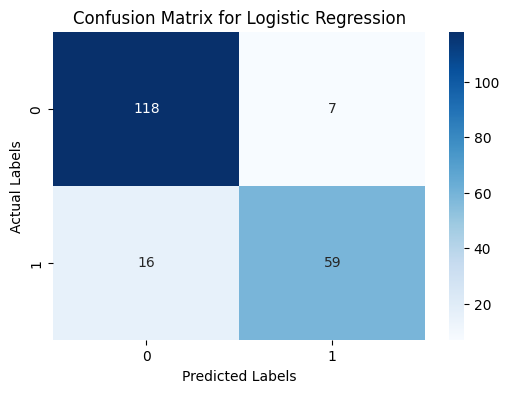

In [14]:
# Visualization

plt.figure(figsize =(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')

plt.show()

## Classification Report

The classification report provides Precision, Recall, F1 Score, and Support for each class.

In [15]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       125
           1       0.89      0.79      0.84        75

    accuracy                           0.89       200
   macro avg       0.89      0.87      0.87       200
weighted avg       0.89      0.89      0.88       200



# Model 2: Decision Tree Classifier

Decision Trees classify observations by learning a sequence of decision rules from the training data.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Train

dt_model = DecisionTreeClassifier(
    random_state = 42
)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
# predict

y_pred_dt = dt_model.predict(X_test)

In [18]:
# metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

dt_roc_auc = roc_auc_score(y_test, y_pred_dt)


In [19]:
print("Decision Tree Results")
print("-"*40)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Decision Tree Results
----------------------------------------
Accuracy : 0.8
Precision: 0.7272727272727273
Recall   : 0.7466666666666667
F1 Score : 0.7368421052631579
ROC-AUC  : 0.7893333333333332


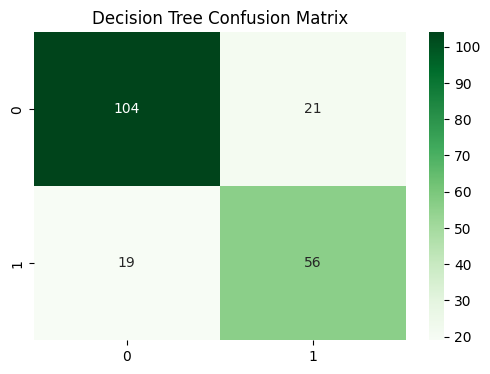

In [20]:
# confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [29]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       125
           1       0.73      0.75      0.74        75

    accuracy                           0.80       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.80      0.80      0.80       200



# Model 3: Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test
)

In [31]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_roc_auc = roc_auc_score(y_test, y_pred_rf)

In [32]:
print("Random Forest Results")
print("-"*40)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
----------------------------------------
Accuracy : 0.875
Precision: 0.890625
Recall   : 0.76
F1 Score : 0.8201438848920863
ROC-AUC  : 0.852


In [33]:
# Model comparision

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    'Precision': [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    'Recall': [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    'F1 Score': [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    'ROC-AUC': [
        lr_roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.885,0.893939,0.786667,0.836879,0.865333
1,Decision Tree,0.800,0.727273,0.746667,0.736842,0.789333
2,Random Forest,0.875,0.890625,0.760000,0.820144,0.852000


# Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV to identify the optimal parameter combination for the Logistic Regression model.

In [35]:
from sklearn.model_selection import GridSearchCV

# parameter grid

params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}



In [36]:
# Grid search
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [37]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'C': 10, 'solver': 'lbfgs'}


In [38]:
print("Best Cross Validation Score:")
print(grid_lr.best_score_)

Best Cross Validation Score:
0.8574999999999999


In [39]:
# train tuned model
best_lr = grid_lr.best_estimator_

In [40]:
# predictions
y_pred_tuned = best_lr.predict(X_test)

In [41]:
# Evaluate Tuned model
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_tuned))

Accuracy : 0.845
Precision: 0.8928571428571429
Recall   : 0.6666666666666666
F1 Score : 0.7633587786259542
ROC-AUC  : 0.8093333333333332


# Feature Importance Analysis

The coefficients of the Logistic Regression model are used to identify the features that have the greatest impact on loan approval prediction.

In [42]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0]
})

feature_importance

,Feature,Coefficient
0,Unnamed: 0,1.297371e-03
1,Applicant_Income,-5.928563e-06
2,Coapplicant_Income,-2.102194e-05
3,Loan_Amount,2.481167e-07
4,Credit_History,-1.708394e-01
5,CIBIL_Score,-5.325582e-03
6,Employment_Status,1.292510e-01
7,Existing_EMIs,8.444544e-06
8,Debt_to_Income_Ratio,2.466671e+00
9,Education,2.537939e-02


In [43]:
# Sort

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient
8,Debt_to_Income_Ratio,2.466671e+00
6,Employment_Status,1.292510e-01
10,Property_Area,4.214068e-02
9,Education,2.537939e-02
0,Unnamed: 0,1.297371e-03
7,Existing_EMIs,8.444544e-06
3,Loan_Amount,2.481167e-07
1,Applicant_Income,-5.928563e-06
2,Coapplicant_Income,-2.102194e-05
5,CIBIL_Score,-5.325582e-03


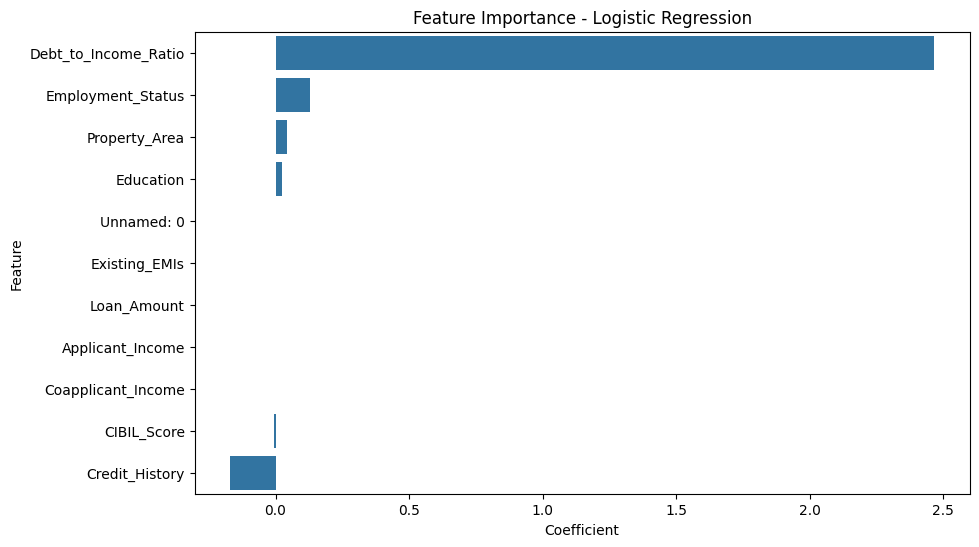

In [44]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

# Final Model Summary

Three classification algorithms were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Based on Accuracy, Precision, F1 Score, and ROC-AUC, Logistic Regression achieved the best overall performance.

Hyperparameter tuning was performed using GridSearchCV, and the tuned Logistic Regression model was selected as the final model for loan approval prediction.

In [45]:
import os

os.makedirs(
    "/content/drive/MyDrive/Machine_Learning/models",
    exist_ok=True
)

In [46]:
import joblib

joblib.dump(
    best_lr,
    "/content/drive/MyDrive/Machine_Learning/models/loan_approval_model.pkl"
)

['/content/drive/MyDrive/Machine_Learning/models/loan_approval_model.pkl']